In [2]:
import streamlit as st
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
df=pd.read_csv(r'c:\Users\ELZAHBIA\AppData\Local\Temp\Rar$DRa8732.48113\Churn_Modelling.csv')
df=df.drop(columns=['RowNumber'])
print(df.head())

   CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0    15634602  Hargrave          619    France  Female   42       2   
1    15647311      Hill          608     Spain  Female   41       1   
2    15619304      Onio          502    France  Female   42       8   
3    15701354      Boni          699    France  Female   39       1   
4    15737888  Mitchell          850     Spain  Female   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1        101348.88   
1   83807.86              1          0               1        112542.58   
2  159660.80              3          1               0        113931.57   
3       0.00              2          0               0         93826.63   
4  125510.82              1          1               1         79084.10   

   Exited  
0       1  
1       0  
2       1  
3       0  
4       0  


In [3]:
columns=df.columns
print(columns)

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')


In [4]:
describe=df.describe().round(2)
print(describe)

        CustomerId  CreditScore       Age    Tenure    Balance  NumOfProducts  \
count     10000.00     10000.00  10000.00  10000.00   10000.00       10000.00   
mean   15690940.57       650.53     38.92      5.01   76485.89           1.53   
std       71936.19        96.65     10.49      2.89   62397.41           0.58   
min    15565701.00       350.00     18.00      0.00       0.00           1.00   
25%    15628528.25       584.00     32.00      3.00       0.00           1.00   
50%    15690738.00       652.00     37.00      5.00   97198.54           1.00   
75%    15753233.75       718.00     44.00      7.00  127644.24           2.00   
max    15815690.00       850.00     92.00     10.00  250898.09           4.00   

       HasCrCard  IsActiveMember  EstimatedSalary   Exited  
count   10000.00        10000.00         10000.00  10000.0  
mean        0.71            0.52        100090.24      0.2  
std         0.46            0.50         57510.49      0.4  
min         0.00          

In [5]:
duplication=df.duplicated().sum()
print(duplication)

0


In [6]:
null=df.isna().sum()
print(null)

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [8]:
churn_data = df.groupby(['Geography', 'Exited']).size().reset_index(name='Count')
churn_data['Status'] = churn_data['Exited'].map({0: 'Stay', 1: 'Exited'})

germany_exited = df[
    (df['Geography'] == 'Germany') &
    (df['Exited'] == 1)
]

gender_counts = germany_exited['Gender'].value_counts()

male = gender_counts.get('Male', 0)
female = gender_counts.get('Female', 0)

gender_text = f"Male: {male} | Female: {female}"
fig = px.bar(
    churn_data,
    x='Count',
    y='Geography',
    color='Geography',
    orientation='h',
    barmode='group',
    text='Count',
    title='Churn Count per Country',
    color_discrete_map={
        'Germany': '#B71C1C',  # dark red
        'France': '#E53935',   # medium red
        'Spain': '#EF9A9A'     # light red
    }
)

# تحسين المظهر وإخفاء المحور X
fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis=dict(visible=False), 
    plot_bgcolor='white',
    showlegend=False
)

fig.update_layout(
    title=dict(
        text='Churn Count per Countrye',
        x=0.01,         
        y=0.98,         
        xanchor='left',
        yanchor='top'
    ))
fig.add_annotation(
    x=gender_counts.sum() / 2,
    y='Germany',
    text=gender_text,
    showarrow=False,
    font=dict(size=13, color='white')
)
fig.add_shape(
    type='rect',
    xref='paper',
    yref='y',
    x0=0,
    x1=0.51,
    y0=0.5,
    y1=1.5,
    line=dict(
        color='#e74c3c',
        width=3,
        dash='dash'
    ),
    fillcolor='rgba(0,0,0,0)'
)
fig.update_yaxes(
    title=None,
    showticklabels=True
)
fig.show()
#continuity

In [ ]:
female_age = (
    df[
        (df['Geography'] == 'Germany') &
        (df['Exited'] == 1) &
        (df['Gender'] == 'Female')
    ]
    .groupby('Age')
    .size()
    .reset_index(name='Count')
)

# إجمالي عدد النساء في Germany
total_female_germany = df[
    (df['Geography'] == 'Germany') &
    (df['Gender'] == 'Female')
].shape[0]

# النسبة من إجمالي النساء
female_age['Percentage'] = (
    female_age['Count'] / total_female_germany
) * 100

focus = female_age[female_age['Count'] > 10].reset_index(drop=True)

print(focus)

peak = focus[
    (focus['Age'] >= 39) &
    (focus['Age'] <= 48)
]


fig = px.scatter(
    focus,
    x='Age',
    y='Count',
    title='Germany Female Churn by Age',
    labels={
        'Age': 'Age',
        'Count': 'Female Churn Count'
    },
    text='Count',
    
)
fig.add_scatter(
    x=peak['Age'],
    y=peak['Count'],
    mode='markers+text',
    marker=dict(
        color='green',
        size=10
    ),
    text=peak['Count'],
    textposition='top center',
    showlegend=False
)
#fig.update_traces(textposition='inside')
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(visible=True),
    yaxis=dict(showgrid=True)
   
)
fig.add_vrect(
    x0=39, x1=48,
    fillcolor='#e74c3c',
    opacity=0.12,
    line_width=2,
    line_color='#e74c3c',
    line_dash='dash',
    layer='below',
    annotation_text='Peak Churn (39-48)',
    annotation_position='top left',
    annotation_font=dict(size=12, color='#e74c3c')
)
fig.show()
#من ستات ألمانيا اللي مشيوا، حوالي 40% بس في الفئة دي



    Age  Count  Percentage
0    35     14    1.173512
1    37     19    1.592624
2    38     11    0.922045
3    39     21    1.760268
4    40     15    1.257334
5    41     11    0.922045
6    42     12    1.005868
7    43     21    1.760268
8    44     18    1.508801
9    45     22    1.844091
10   46     20    1.676446
11   47     20    1.676446
12   48     21    1.760268
13   49     17    1.424979
14   50     11    0.922045
15   51     19    1.592624
16   54     11    0.922045
17   55     12    1.005868
18   57     11    0.922045


In [ ]:
churn_per_sex = (
    df.groupby('Gender')['Exited']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index(name='Percentage')
)

churn_per_sex['Status'] = churn_per_sex['Exited'].map({0: 'Stay', 1: 'Exited'})
churn_per_sex['pct_label'] = churn_per_sex['Percentage'].apply(lambda x: f"{x:.1f}%")

fig = px.bar(
    churn_per_sex, 
    x='Gender', 
    y='Percentage', 
    color='Status', 
    text='pct_label', 
    title='Churn Rate Distribution by Gender',
    color_discrete_map={'Stay': 'Gray', 'Exited': '#e74c3c'} # أخضر للمستمرين وأحمر للمغادرين
)

fig.update_traces(textposition='inside')
fig.update_yaxes(visible=False)
fig.update_xaxes(title='Gender')
fig.update_layout(
    barmode='stack',
    plot_bgcolor='white',
    legend_title_text='Status',
    legend=dict(
        yanchor="top",
        y=1.1,
        xanchor="left",
        x=0.01,
        orientation="h"
    )

)


fig.show()

In [ ]:

churn_per_age = (
    df.groupby('Age')['Exited']
    .value_counts()
    .reset_index(name='Count')
)

churn_per_age['Status'] = churn_per_age['Exited'].map({0: 'Stay', 1: 'Exited'})

# النسبة والإجمالي لكل سن
churn_per_age['Total_Age'] = churn_per_age.groupby('Age')['Count'].transform('sum')
churn_per_age['Percentage'] = (churn_per_age['Count'] / churn_per_age['Total_Age']) * 100

churn_per_age = churn_per_age.sort_values('Age')

fig = px.line(
    churn_per_age,
    x='Age',
    y='Count',
    color='Status',
    markers=False,
    custom_data=['Percentage', 'Total_Age'],
    title='Customer Churn Distribution by Age',
    color_discrete_map={'Stay': 'Gray', 'Exited': '#e74c3c'}
)
peak_data = churn_per_age[
    (churn_per_age['Age'] >= 49) &
    (churn_per_age['Age'] <= 60) &
    (churn_per_age['Exited'] == 1)
]

fig.add_scatter(
    x=peak_data['Age'],
    y=peak_data['Count'],
    mode='text',
    text=peak_data['Percentage'].map(lambda x: f'{x:.1f}%'),
    textposition='top center',
    showlegend=False,
    hoverinfo='skip'
)
fig.update_traces(
    hovertemplate="<br>".join([
        "<b>Age:</b> %{x}",
        "<b>Count:</b> %{y}",
        "<b>Percentage:</b> %{customdata[0]:.1f}%",
        "<b>Total in Age Group:</b> %{customdata[1]}"
    ])
)

fig.update_layout(
    title=dict(
        text='Customer Churn Distribution by Age',
        x=0.01,
        y=0.98,
        xanchor='left',
        yanchor='top'
    ),
    legend=dict(
        yanchor="top",
        y=1.2,
        xanchor="left",
        x=0.01,
        orientation="h"
    ),
    xaxis_title='Age',
    yaxis_title='Number of Customers',
    plot_bgcolor='white',
    hovermode='x unified',
    legend_title_text='Status'
)

fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0')
fig.update_yaxes(showgrid=True, gridcolor='#f0f0f0')

# المنطقة من 49 لـ 60
fig.add_vrect(
    x0=49, x1=60,
    fillcolor='#e74c3c',
    opacity=0.12,
    line_width=2,
    line_color='#e74c3c',
    line_dash='dash',
    layer='below',
    annotation_text='Peak Churn (49-60)',
    annotation_position='top left',
    annotation_font=dict(size=12, color='#e74c3c')
)

fig.show()
#connection
#enclosure
#remove marker

In [ ]:
df_49_60 = df[df['Age'].between(49, 60)]
group_rate = df_49_60['Exited'].mean() * 100          # 55.10
overall_rate = df['Exited'].mean() * 100              # 20.37
share_of_exited = (
    df_49_60['Exited'].sum() / df['Exited'].sum() * 100   # 29.16
)

plot_df = pd.DataFrame({
    'Group': ['Customers aged 49-60', 'All customers'],
    'Churn Rate': [group_rate, overall_rate],
})
plot_df['label'] = plot_df['Churn Rate'].apply(lambda x: f"{x:.1f}%")

fig = px.bar(
    plot_df,
    x='Group',
    y='Churn Rate',
    text='label',
    color='Group',
    color_discrete_map={
        'Customers aged 49-60': '#e74c3c',
        'All customers': '#bdc3c7',
    },
    title='Customers aged 49-60 are 2.7x more likely to leave than average',
)

fig.update_traces(textposition='outside')

fig.add_annotation(
    x=0.98, y=1.0, xref='paper', yref='paper',
    text=(f"{share_of_exited:.1f}% of all churned customers<br>"
          f"are in this age group"),
    showarrow=False,
    align='left',
    font=dict(size=13, color='gray'),
)

fig.update_layout(
    showlegend=False,
    plot_bgcolor='white',
    xaxis_title=None,
    yaxis_title='Churn Rate (%)',
    yaxis_range=[0, 70],
)
fig.update_yaxes(showgrid=True, gridcolor='#f0f0f0')

fig.show()

In [41]:
df['Balance_Group'] = pd.cut(
    df['Balance'],
    bins=[-1, 0, 50000, 100000, 150000, 250000],
    labels=['0 Balance', '1 - 50k', '50k - 100k', '100k - 150k', '150k+']
)

bal = (
    df.groupby('Balance_Group', observed=False)['Exited']
    .agg(rate='mean', n='count')
    .reset_index()
)
bal['rate'] = bal['rate'] * 100
overall = df['Exited'].mean() * 100

bal['label_x'] = bal.apply(lambda r: f"{r['Balance_Group']}<br>(n={int(r['n']):,})", axis=1)

# نلوّن أعلى شريحة بس بين الشرائح الكبيرة (500 عميل فأكتر)
big = bal[bal['n'] >= 500]
top_group = big.loc[big['rate'].idxmax(), 'Balance_Group']
low_group = big.loc[big['rate'].idxmin(), 'Balance_Group']
colors = ['#e74c3c' if g == top_group else '#bdc3c7' for g in bal['Balance_Group']]

top_rate = big['rate'].max()
low_rate = big['rate'].min()

fig = go.Figure(go.Bar(
    x=bal['label_x'],
    y=bal['rate'],
    marker_color=colors,
    text=bal['rate'].apply(lambda x: f"{x:.1f}%"),
    textposition='outside',
))

fig.add_hline(
    y=overall, line_dash='dash', line_color='gray',
    annotation_text=f"Bank average: {overall:.1f}%",
    annotation_position='top left',
)

fig.update_layout(
    title=dict(
        text=f"Customers with {top_group} balance churn at {top_rate:.1f}%, "
             f"almost {top_rate / low_rate:.1f}x the rate of {low_group} customers ({low_rate:.1f}%)",
        x=0.01, xanchor='left',
    ),
    plot_bgcolor='white',
    showlegend=False,
    xaxis_title='Balance Range',
    yaxis_title=None,
    yaxis_range=[0, 45],
)
fig.update_yaxes(showgrid=False, visible=False)

fig.show()

In [ ]:
prod = (df.groupby('NumOfProducts')['Exited'].agg(rate='mean', n='count').reset_index())
prod['rate'] = prod['rate'] * 100
overall = df['Exited'].mean() * 100

# 2. تسمية المحور: القيمة + عدد العملاء تحتها
prod['label_x'] = prod.apply(lambda r: f"{int(r['NumOfProducts'])} products<br>(n={int(r['n']):,})", axis=1)
prod['NumOfProducts'] = pd.Categorical(
    prod['NumOfProducts'],
    categories=[ 4, 3,2, 1],
    ordered=True
)

prod = prod.sort_values('NumOfProducts')
# ترتيب الألوان: Product 1 → 3 → 4 → 2
blue_colors = {
    1: '#0057B8',
    3: '#9DC3E6',
    4: '#D9EAF7',
    2: '#5B9BD5'
}

colors = prod['NumOfProducts'].map(blue_colors)

fig = go.Figure(go.Bar(
    x=prod['rate'],
    y=prod['label_x'],
    marker_color=colors,
    text=prod['rate'].apply(lambda x: f"{x:.1f}%"),
    textposition='inside',
    orientation='h'
))

# Bank average
fig.add_vline(
    x=overall,
    line_dash='dash',
    line_color='gray',
    annotation_text=f"Bank average: {overall:.1f}%",
    annotation_position='top'
)

fig.update_layout(
    title='Churn Rate by Number of Products',
    xaxis_title='Churn Rate (%)',
    yaxis_title=None,
    xaxis_range=[0, 100],
    plot_bgcolor='white',
    showlegend=False
)

fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0')
fig.update_yaxes(showgrid=False)

fig.show()
#focus on the customer who getting 1 product cuz they have huge n of customer with high customers who lefted

In [ ]:
print(df['Exited'].value_counts())
customers_prod_1=((df["Exited"]==1)&(df['NumOfProducts']==1)).sum()
print(customers_prod_1)
perc=(customers_prod_1/(df['Exited']==1).sum())*100
print(f'custemr_left form product1: {perc:.1f}%')
total=df['Exited'].value_counts().sum()
print(total)
final_calc=(customers_prod_1/total)*100
print(f'customer left from product1 from whole bank:{final_calc :.1f}%')
total_prod_1=(df['NumOfProducts']==1).sum()
print(total_prod_1)
final_prod_1=(total_prod_1/total)*100
print(f'customer who has product1 from whole bank:{final_prod_1 :.1f}%')
print('''المجموعة 1 (عملاء المنتج الواحد) هي نص عملاء البنك تقريبًا (50.8%). لكنها 69.2% من كل اللي سابوا البنك. يعني حصتها بين اللي مشيوا أكبر من حجمها.

وكمان:

كل عميل في المجموعة 1 احتمال إنه يمشي 27.7%، وده أعلى من متوسط البنك (20.4%).''')

Exited
0    7963
1    2037
Name: count, dtype: int64
1409
custemr_left form product1: 69.2%
10000
customer left from product1 from whole bank:14.1%
5084
customer who has product1 from whole bank:50.8%
المجموعة 1 (عملاء المنتج الواحد) هي نص عملاء البنك تقريبًا (50.8%). لكنها 69.2% من كل اللي سابوا البنك. يعني حصتها بين اللي مشيوا أكبر من حجمها.

وكمان:

كل عميل في المجموعة 1 احتمال إنه يمشي 27.7%، وده أعلى من متوسط البنك (20.4%).


Exited              0      1
IsActiveMember              
0               73.15  26.85
1               85.73  14.27
leakage= 26.85/14.27= 1.9 inactive that man the inactive out 1.9 more than active
Exited             0     1
IsActiveMember            
0               3547  1302
1               4416   735


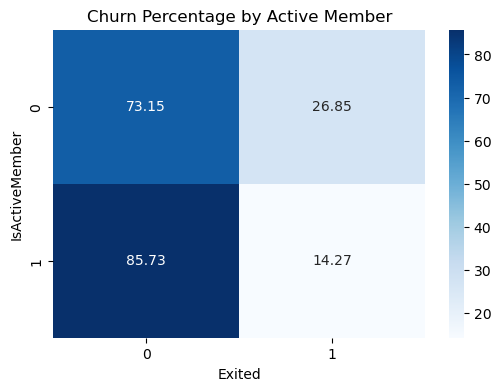

In [ ]:
#IsActiveMember
import matplotlib.pyplot as plt
import seaborn as sns
active_pers= pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index')*100
print(active_pers.round(2))
print('leakage= 26.85/14.27= 1.9 inactive that man the inactive out 1.9 more than active')
active= pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],)
print(active)
plt.figure(figsize=(6, 4))
sns.heatmap(
    active_pers,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Churn Percentage by Active Member')
plt.xlabel('Exited')
plt.ylabel('IsActiveMember')
plt.show()


In [ ]:
#dummy
df3 = df.copy()

new_df = pd.get_dummies(df3.iloc[:, 3:5],dtype=int)

df3 = pd.concat([
    df3.iloc[:, :3],
    new_df,
    df3.iloc[:, 5:]
], axis=1)
print(df3)

      CustomerId    Surname  CreditScore  Geography_France  Geography_Germany  \
0       15634602   Hargrave          619                 1                  0   
1       15647311       Hill          608                 0                  0   
2       15619304       Onio          502                 1                  0   
3       15701354       Boni          699                 1                  0   
4       15737888   Mitchell          850                 0                  0   
...          ...        ...          ...               ...                ...   
9995    15606229   Obijiaku          771                 1                  0   
9996    15569892  Johnstone          516                 1                  0   
9997    15584532        Liu          709                 1                  0   
9998    15682355  Sabbatini          772                 0                  1   
9999    15628319     Walker          792                 1                  0   

      Geography_Spain  Gend

In [ ]:
#prediction
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


#prediction
X=df3.iloc[:,3:-3].to_numpy()
print(X)
y=df3.iloc[:,-2].to_numpy()
print(y)



[[1. 0. 0. ... 1. 1. 1.]
 [0. 0. 1. ... 1. 0. 1.]
 [1. 0. 0. ... 3. 1. 0.]
 ...
 [1. 0. 0. ... 1. 0. 1.]
 [0. 1. 0. ... 2. 1. 0.]
 [1. 0. 0. ... 1. 1. 0.]]
[1 0 1 ... 1 1 0]


In [ ]:
#preprocessing
min_max=MinMaxScaler()
X=min_max.fit_transform(X)
print(X)

[[1.         0.         0.         ... 0.         1.         1.        ]
 [0.         0.         1.         ... 0.         0.         1.        ]
 [1.         0.         0.         ... 0.66666667 1.         0.        ]
 ...
 [1.         0.         0.         ... 0.         0.         1.        ]
 [0.         1.         0.         ... 0.33333333 1.         0.        ]
 [1.         0.         0.         ... 0.         1.         0.        ]]


In [ ]:
#Splitting
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.33)

In [ ]:
#model
RFC=RandomForestClassifier(n_estimators=400,max_depth=7,min_samples_split=3)
RFC.fit(X_train,y_train)
y_pred=RFC.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 1]


In [ ]:
#validation
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
cm=confusion_matrix(y_test,y_pred)
aas=accuracy_score(y_test,y_pred)
cr=classification_report(y_test,y_pred,output_dict=True)
print(cr)
print(f'accuracy: {aas:.2f}')
print(cm)

{'0': {'precision': 0.8761390482618967, 'recall': 0.9770417764395936, 'f1-score': 0.9238434163701068, 'support': 2657.0}, '1': {'precision': 0.8189910979228486, 'recall': 0.42923794712286156, 'f1-score': 0.563265306122449, 'support': 643.0}, 'accuracy': 0.8703030303030304, 'macro avg': {'precision': 0.8475650730923727, 'recall': 0.7031398617812276, 'f1-score': 0.7435543612462778, 'support': 3300.0}, 'weighted avg': {'precision': 0.8650038567261367, 'recall': 0.8703030303030304, 'f1-score': 0.8535853179188208, 'support': 3300.0}}
accuracy: 0.87
[[2596   61]
 [ 367  276]]


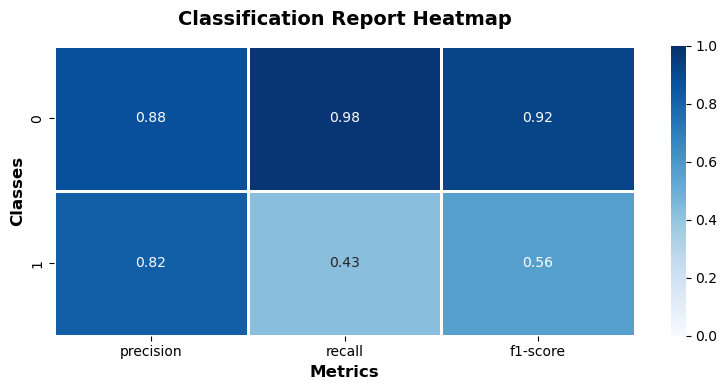

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns 
cr_df = pd.DataFrame(cr).T

report_metrics = cr_df.iloc[:-3, :-1]

plt.figure(figsize=(8, 4))
sns.heatmap(
    report_metrics, 
    annot=True, 
    cmap='Blues', 
    fmt='.2f', 
    linewidths=1, 
    cbar=True,
    vmin=0, 
    vmax=1
)

plt.title('Classification Report Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Classes', fontsize=12, fontweight='bold')
plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

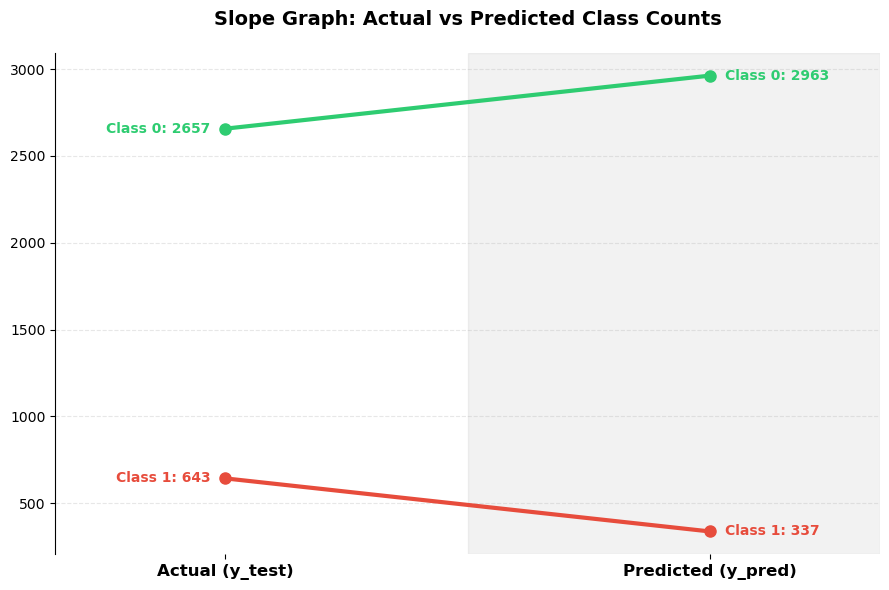

In [ ]:
actual_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

classes = sorted(list(set(y_test) | set(y_pred)))

plt.figure(figsize=(9, 6))
x1, x2 = 0, 1

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f1c40f']

for idx, cls in enumerate(classes):
    y1 = actual_counts.get(cls, 0)
    y2 = pred_counts.get(cls, 0)
    color = colors[idx % len(colors)]

    plt.plot([x1, x2], [y1, y2], marker='o', markersize=8, linewidth=3,
             color=color, label=f'Class {cls}')

    plt.text(x1 - 0.03, y1, f"Class {cls}: {y1}", ha='right', va='center',
             fontweight='bold', color=color)
    plt.text(x2 + 0.03, y2, f"Class {cls}: {y2}", ha='left', va='center',
             fontweight='bold', color=color)

plt.xticks([x1, x2], ['Actual (y_test)', 'Predicted (y_pred)'],
           fontsize=12, fontweight='bold')
plt.xlim(-0.35, 1.35)

plt.axvspan(0.5, 1.35, color='grey', alpha=0.1, zorder=0)

plt.title('Slope Graph: Actual vs Predicted Class Counts',
          fontsize=14, fontweight='bold', pad=20)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
#closure